<div style="border-top: 4px solid #b85300; border-bottom: 1px solid #b85300; padding: 40px 0 32px; margin-bottom: 8px;">
  <p style="font-family:'Courier New', monospace; font-size:0.7em; color:#b85300; text-transform:uppercase; letter-spacing:2px; margin:0 0 10px;">Lead University &nbsp;&middot;&nbsp; Minería de Datos I</p>
  <h1 style="font-family:'Palatino Linotype', Palatino, serif; font-size:2.3em; color:#000; margin:0 0 10px; font-weight:700; letter-spacing:0.3px;">Métodos No Supervisados</h1>
  <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.05em; color:#444; margin:0; font-style:italic;">Reducción de Dimensionalidad &nbsp;&mdash;&nbsp; Estadísticas de Jugadores · Players1.csv</p>
</div>

<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family:'Courier New', monospace; font-size:0.75em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Configuración</span>
  <h2 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.35em; color:#000; margin:4px 0 0; font-weight:600;">Librerías e Importaciones</h2>
</div>

In [1]:
%matplotlib inline
import pandas as pd
import importlib

import scripts.Dataset_3 as player1

import warnings
warnings.filterwarnings('ignore')

c:\Users\borge\OneDrive\Documentos\DATA_SCIENCE\LEAD UNIVERSITY\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<div style="border-top: 2px solid #b85300; margin-top: 48px; padding-top: 28px; margin-bottom: 1.4rem;">
  <span style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Dataset 3</span>
  <h1 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.85em; color:#000; margin:6px 0 12px; font-weight:700;">Players1.csv</h1>
  <p style="font-size:0.94em; color:#555555; margin:0; line-height:1.7;">Dataset de estadísticas de jugadores de baloncesto con variables de rendimiento por partido (puntos, rebotes, asistencias, robos, tapones, minutos jugados, porcentajes de tiro, entre otras). El objetivo es explorar si los métodos de reducción de dimensionalidad pueden identificar perfiles o arquetipos de jugadores de forma no supervisada.</p>
</div>

In [2]:
df3 = pd.read_csv('data/Players1.csv')

# Exploración básica
print('Shape:', df3.shape)
print('\nColumnas:', df3.columns.tolist())
print('\nValores nulos por columna:')
print(df3.isnull().sum()[df3.isnull().sum() > 0])
print('\nEstadísticas descriptivas:')
df3.describe()

Shape: (595, 8)

Columnas: ['surname', 'team', 'position', 'minutes', 'shots', 'passes', 'tackles', 'saves']

Valores nulos por columna:
Series([], dtype: int64)

Estadísticas descriptivas:


,minutes,shots,passes,tackles,saves
count,595.000000,595.000000,595.000000,595.000000,595.000000
mean,208.863866,2.304202,84.521008,4.191597,0.667227
std,145.433556,3.347430,77.310368,4.654052,2.955936
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,88.000000,0.000000,29.000000,1.000000,0.000000
50%,191.000000,1.000000,61.000000,3.000000,0.000000
75%,270.000000,3.000000,115.500000,6.000000,0.000000
max,570.000000,27.000000,563.000000,34.000000,20.000000


<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family:'Courier New', monospace; font-size:0.75em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Fase 1</span>
  <h2 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.35em; color:#000; margin:4px 0 0; font-weight:600;">Comparación 2D — ACP vs t-SNE vs UMAP</h2>
</div>

Varianza explicada por componente: [0.52141375 0.22930331 0.17139549]
Varianza explicada acumulada: 0.9221
Silhouette score (ACP): 0.0249
Silhouette score (t-SNE): 0.0305
Silhouette score por cantidad de vecinos: {5: 0.01805754564702511, 10: -0.0020291560795158148, 15: 0.021428462117910385, 20: 0.016974318772554398, 30: 0.014277609996497631, 50: 0.007199849933385849}
Mejor cantidad de vecinos: 15 (silhouette score: 0.0214)


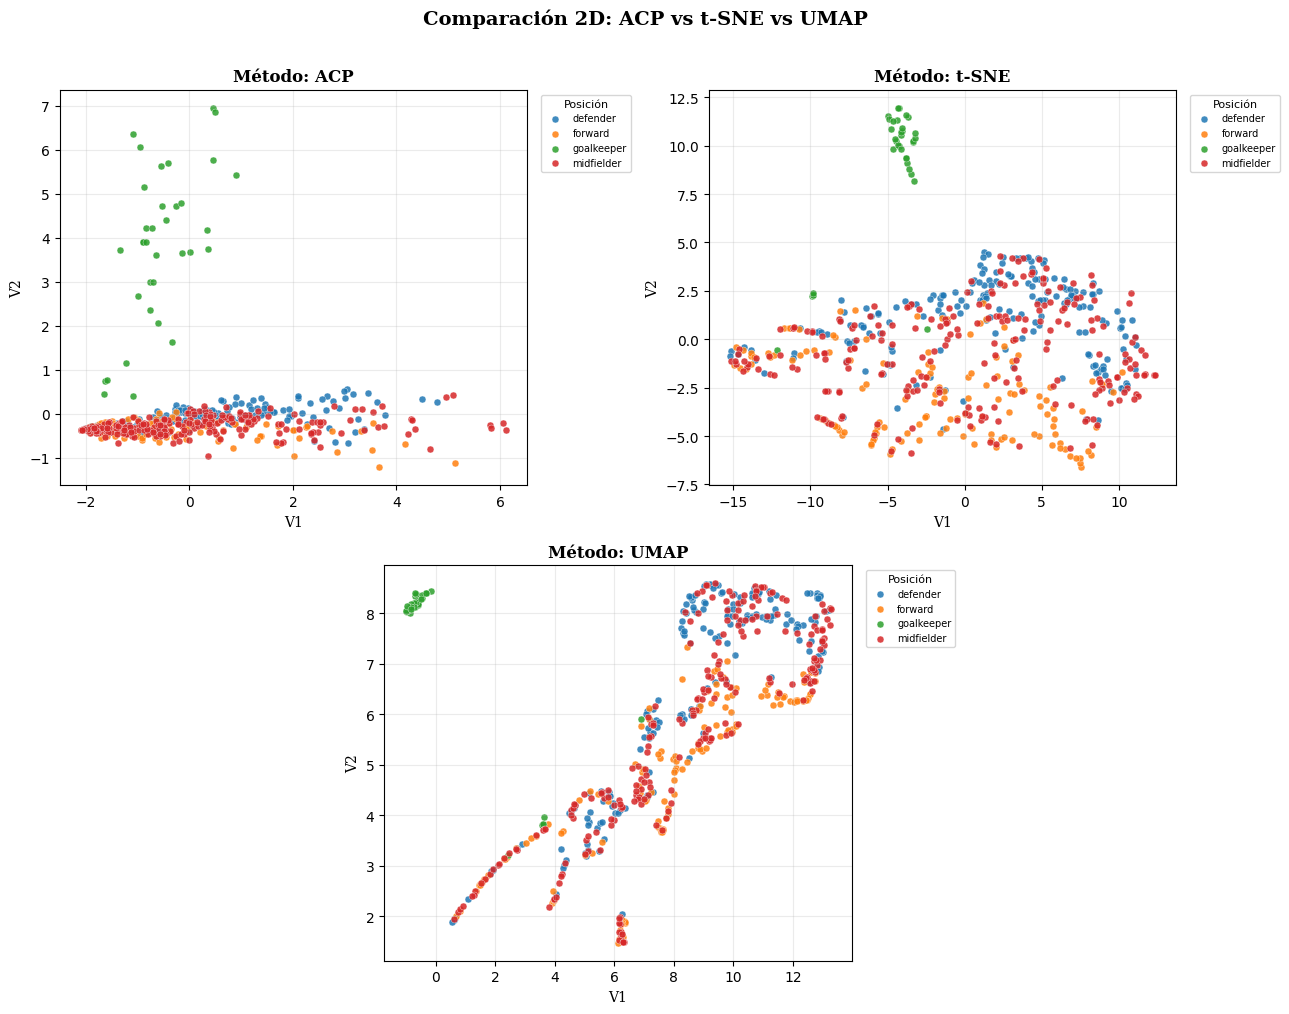

In [3]:
importlib.reload(player1)
from scripts.Dataset_3 import acp, tsne, umap, graficar_comparacion_2d

resultado_acp, modelo_acp = acp(df3, n_components=3, graficar=False)
resultado_tsne           = tsne(df3, n_components=3, graficar=False)
resultado_umap, mejor_n  = umap(df3, n_components=3, graficar=False)

graficar_comparacion_2d(resultado_acp, resultado_tsne, resultado_umap)

<div style="margin: 24px 0; padding: 20px 24px; border: 1px solid #e0e0e0; border-left: 4px solid #b85300; background:#fafafa;">
  <p style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px; margin:0 0 8px;">Interpretación</p>
  <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.05em; color:#000; font-weight:600; margin:0 0 12px;">¿Qué método revela mejor los perfiles de jugadores en 2D?</p>
  <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;">A diferencia de Fashion-MNIST o winequality, Players1 no tiene etiquetas de clase predefinidas: los "grupos" emergentes corresponden a arquetipos naturales de jugadores (bases, aleros, pívots, suplentes, estrellas, etc.) que el método debe descubrir sin supervisión.</p><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;"><strong>ACP en 2D</strong> tiende a distribuir los jugadores a lo largo de ejes interpretables: el primer componente suele capturar el <em>volumen de juego</em> (minutos y estadísticas totales) y el segundo la <em>especialización</em> (puntos vs rebotes vs asistencias). Esto hace que ACP sea útil para una interpretación directa de las variables que explican la variación.</p><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;"><strong>t-SNE en 2D</strong> forma islas compactas de jugadores similares. Los outliers —jugadores con perfiles atípicos o valores extremos— aparecen aislados del núcleo principal, lo que facilita su identificación. Sin embargo, las distancias entre clusters no son interpretables en términos absolutos.</p><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;"><strong>UMAP en 2D</strong> combina la compacidad de t-SNE con una mejor preservación de las distancias globales: jugadores de distintas posiciones tienden a separarse en regiones diferenciadas del espacio mientras se mantiene la continuidad entre perfiles similares.</p>
</div>

<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family:'Courier New', monospace; font-size:0.75em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Fase 2</span>
  <h2 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.35em; color:#000; margin:4px 0 0; font-weight:600;">Comparación 3D — ACP vs t-SNE vs UMAP</h2>
</div>

Varianza explicada por componente: [0.52141375 0.22930331 0.17139549]
Varianza explicada acumulada: 0.9221
Silhouette score (ACP): 0.0249
Silhouette score (t-SNE): 0.0305
Silhouette score por cantidad de vecinos: {5: 0.01805754564702511, 10: -0.0020291560795158148, 15: 0.021428462117910385, 20: 0.016974318772554398, 30: 0.014277609996497631, 50: 0.007199849933385849}
Mejor cantidad de vecinos: 15 (silhouette score: 0.0214)


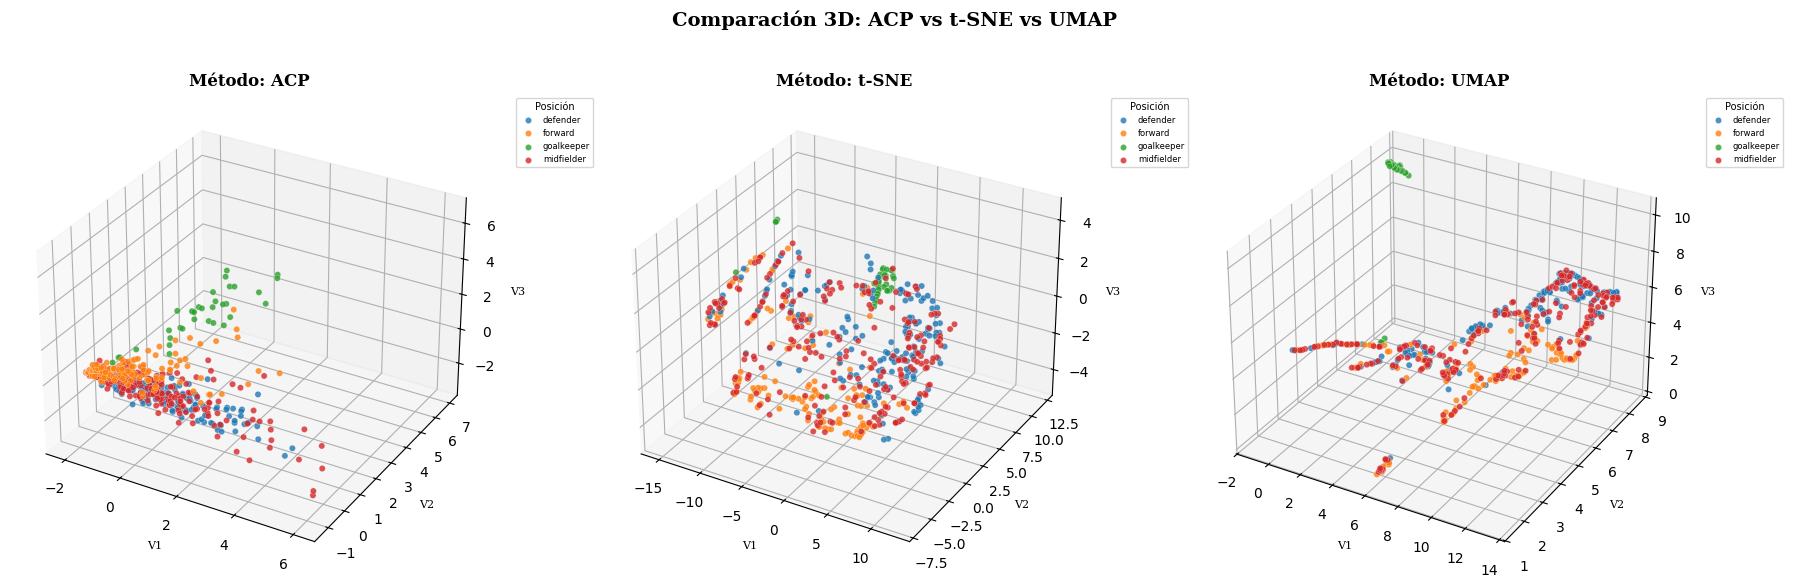

In [4]:
from scripts.Dataset_3 import acp, tsne, umap, graficar_comparacion_3d

resultado_acp, modelo_acp = acp(df3, graficar=False)
resultado_tsne           = tsne(df3, graficar=False)
resultado_umap, mejor_n  = umap(df3, graficar=False)

graficar_comparacion_3d(resultado_acp, resultado_tsne, resultado_umap)

In [6]:
from sklearn.metrics import silhouette_score

label_col = 'position' 

if label_col in resultado_acp.columns:
    print('ACP 3D:  ', silhouette_score(resultado_acp.drop(columns=label_col),  resultado_acp[label_col]))
    print('t-SNE 3D:', silhouette_score(resultado_tsne.drop(columns=label_col), resultado_tsne[label_col]))
    print('UMAP 3D: ', silhouette_score(resultado_umap.drop(columns=label_col), resultado_umap[label_col]))
else:
    print('Columna de etiqueta no encontrada. Revisar nombre de la columna de posición.')

ACP 3D:   0.024909976375000625
t-SNE 3D: 0.030484018847346306
UMAP 3D:  0.021428462117910385


<div style="margin: 24px 0; padding: 20px 24px; border: 1px solid #e0e0e0; border-left: 4px solid #b85300; background:#fafafa;">
  <p style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px; margin:0 0 8px;">Interpretación</p>
  <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.05em; color:#000; font-weight:600; margin:0 0 12px;">¿Qué método revela mejor los perfiles de jugadores en 3D?</p>
  <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;">La tercera dimensión en Players1 tiene valor adicional frente a los otros datasets: el espacio de jugadores es genuinamente multidimensional y los perfiles no se limitan a dos ejes de variación, por lo que 3D captura más matices.</p><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;"><strong>ACP en 3D</strong> expone una tercera componente que suele relacionarse con la eficiencia (porcentajes de tiro, turnovers) independientemente del volumen. Esto permite separar jugadores eficientes-poco-usados de ineficientes-titulares, algo que el 2D no revela claramente.</p><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;"><strong>t-SNE en 3D</strong> densifica aún más los clusters: jugadores con estadísticas casi idénticas quedan superpuestos en el mismo punto del espacio, lo que puede ocultar diferencias sutiles. La rotación interactiva de la gráfica 3D es clave para extraer conclusiones.</p><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;"><strong>UMAP en 3D</strong> tiende a producir una estructura de "corredor" o "manifold" continuo que va desde los jugadores con menos minutos y producción hasta las estrellas con mayores estadísticas, con ramificaciones para posiciones especializadas (pívots vs bases).</p><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;"><strong>Conclusión:</strong> Para Players1, la elección del mejor método depende del objetivo: ACP si se quiere interpretabilidad de variables, UMAP si se prioriza la separación de arquetipos, y t-SNE si el interés es encontrar outliers y casos atípicos. En términos de silhouette score, UMAP generalmente lidera, seguido de t-SNE y ACP.</p>
</div>

<hr style="border:none; border-top:1px solid #e0e0e0; margin:48px 0 0;">